# DarkEmulator2 examples

- Matter P(k) emulator for the DarkQuest2 project.
- API reference: [readthedocs](https://dark-emulator2.readthedocs.io/).
- `01_quick_start`: basic emulator usage.
- `02_cosmological_parameter`: valid parameter dictionaries.
- `03a_xi_cl_examples`: ξ(r), C(ℓ), curvature, and source distributions.
- `03b_extended_cosmology_response`: Mnu/w0/wa/Omega_k response and DESI-like scenarios.
- `04_advanced_settings`: optional internal settings.
- `05*` and `06*`: comparison notebooks.

## Native DQ2 parameter set

- Code uses `h0` for reduced Hubble parameter h.
- Exactly one amplitude key is required: `sigma8`, `As`, or `ln(10^10As)`.
- `set_param()` checks ranges and completes dependent parameters.

### Non-linear matter P(k) range

| Code key | Display | Min | Max | Fiducial value |
|---|---:|---:|---:|---:|
| `Omega_m` | $\Omega_\mathrm{m}$ | 0.05 | 0.62 | 0.3156 |
| `omega_b` | $\omega_\mathrm{b}$ | 0.015 | 0.03 | 0.02225 |
| `omega_cdm` | $\omega_\mathrm{cdm}$ | 0.01 | 0.30 | 0.1198 |
| `Mnu` | $M_\nu\,[\mathrm{eV}]$ | 0.0 | 0.5 | 0.06 |
| `Omega_k` | $\Omega_\mathrm{K}$ | -0.1 | 0.1 | 0.0 |
| `Omega_de` | $\Omega_\mathrm{de}$ | 0.4125 | 0.938542 | 0.68434 |
| `sigma8` | $\sigma_8$ | 0.42 | 1.3 | 0.831 |
| `ns` | $n_\mathrm{s}$ | 0.916275 | 1.012725 | 0.9645 |
| `w0` | $w_0$ | -1.5 | -0.5 | -1.0 |
| `wa` | $w_a$ | -0.5 | 0.5 | 0.0 |
| `h0` | $h$ | 0.5 | 0.9 | 0.67235 |
| `ln(10^10As)` | $\ln(10^{10}A_\mathrm{s})$ | 1.0412 | 5.7548 | 3.094 |
| `As` | $A_\mathrm{s}$ | 2.8326e-10 | 3.1570e-08 | 2.2065e-09 |
| `S8` | $S_8$ | 0.60 | 0.95 | 0.85233 |

### Linear matter P(k) range

| Code key | Display | Min | Max | Fiducial value |
|---|---:|---:|---:|---:|
| `Omega_m` | $\Omega_\mathrm{m}$ | 0.03 | 0.64 | 0.3156 |
| `omega_cdm` | $\omega_\mathrm{cdm}$ | 0.005 | 0.35 | 0.1198 |
| `Mnu` | $M_\nu$ | 0.0 | 0.6 | 0.06 |
| `Omega_k` | $\Omega_\mathrm{K}$ | -0.12 | 0.12 | 0.0 |
| `ns` | $n_\mathrm{s}$ | 0.91 | 1.02 | 0.9645 |
| `sigma8` | $\sigma_8$ | 0.46 | 1.36 | 0.831 |
| `h0` | $h$ | 0.5 | 0.9 | 0.67235 |
| `w0` | $w_0$ | -1.6 | -0.4 | -1.0 |
| `wa` | $w_a$ | -0.6 | 0.6 | 0.0 |
| `omega_b` | $\omega_\mathrm{b}$ | 0.01 | 0.04 | 0.02225 |
| `Omega_de` | $\Omega_\mathrm{de}$ | 0.41 | 0.94 | 0.68434 |
| `ln(10^10As)` | $\ln(10^{10}A_\mathrm{s})$ | 0.53 | 6.93 | 3.094 |
| `S8` | $S_8$ | 0.59 | 0.96 | 0.85233 |

### Approximate $\Omega_\mathrm{m}$-$\sigma_8$ support

- The emulator paper describes the exact banana-shaped design.
- `Parameters.get_de2_om_sig8_plane()` returns the practical support curve used for comparison plots.
- Gray dashed: the uncut $S_8$ ellipse mapped to each plane.
- Black solid: the supported curve after the high-$\sigma_8$ side is clipped.


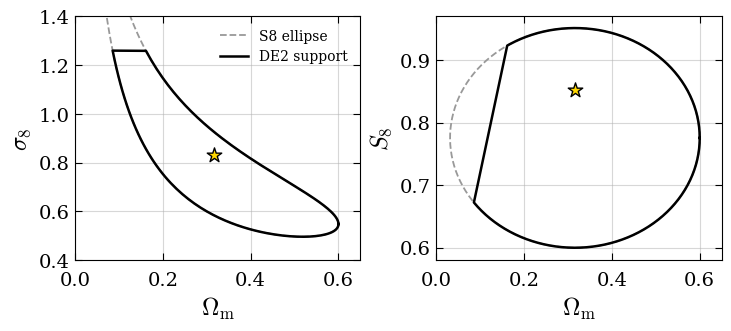

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dark_emulator2.parameters import Parameters

params = Parameters()
om_support, sig8_support = params.get_de2_om_sig8_plane()

om_range = [0.1, 0.6]
sig8_max = 1.25
s8_range = [0.6, 0.95]
om0 = params.fid_param["Omega_m"]
sig80 = params.fid_param["sigma8"]
s80 = sig80 * np.sqrt(om0 / 0.3) * 0.91

theta = np.linspace(0, 2 * np.pi, 256)
om_radius = max(om_range[1] - om0, om0 - om_range[0])
s8_radius = max(s8_range[1] - s80, s80 - s8_range[0])
om_raw = om_radius * np.cos(theta) + om0
s8_raw = s8_radius * np.sin(theta) + s80
sig8_raw = s8_raw / np.sqrt(om_raw / 0.3)
support = sig8_raw < sig8_max * 1.01

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), constrained_layout=True)

axes[0].plot(om_raw, sig8_raw, "--", color="0.6", lw=1.3, label="S8 ellipse")
axes[0].plot(om_support, sig8_support, color="k", lw=1.8, label="DE2 support")
axes[0].scatter([om0], [sig80], marker="*", s=120, color="gold", edgecolor="k", zorder=3)
axes[0].set_xlabel(r"$\Omega_\mathrm{m}$")
axes[0].set_ylabel(r"$\sigma_8$")
axes[0].set_xlim(0, 0.65)
axes[0].set_ylim(0.4, 1.4)
axes[0].legend(frameon=False, fontsize=10, loc="upper right")

axes[1].plot(om_raw, s8_raw, "--", color="0.6", lw=1.3)
axes[1].plot(om_raw[support], s8_raw[support], color="k", lw=1.8)
axes[1].scatter([om0], [sig80 * np.sqrt(om0 / 0.3)], marker="*", s=120, color="gold", edgecolor="k", zorder=3)
axes[1].set_xlabel(r"$\Omega_\mathrm{m}$")
axes[1].set_ylabel(r"$S_8$")
axes[1].set_xlim(0, 0.65)
axes[1].set_ylim(0.58, 0.97)

plt.show()
